<a href="https://colab.research.google.com/github/Barazan19/hf-llm-course-journey/blob/main/ch01_transformer_models_1_3_pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
classifier("I've been waiting for a HuggingFace course my whole life.")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9598048329353333}]

In [3]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
# Masukkan beberapa kalimat sekaligus menggunakan list []
classifier(["Fuck you bitch!", "six feet on the ground"])

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'NEGATIVE', 'score': 0.9845131039619446},
 {'label': 'POSITIVE', 'score': 0.9624295234680176}]

### 🖼️ Contoh Penggunaan Pipeline untuk Image Classification

Di bawah ini, kita akan mendownload sebuah gambar kucing dan membiarkan model AI dari Hugging Face menebak jenis atau isi dari gambar tersebut.

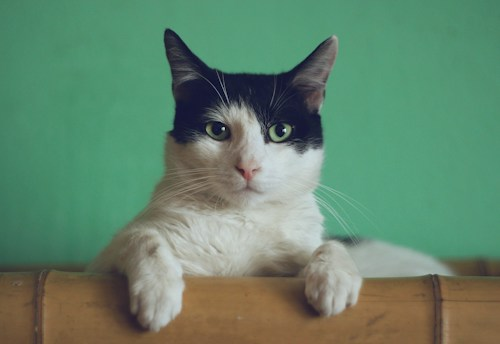

[transformers] No model was supplied, defaulted to google/vit-base-patch16-224 and revision 3f49326.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

=== Hasil Klasifikasi Gambar ===
Label: Egyptian cat | Skor Keyakinan: 0.3845
Label: tabby, tabby cat | Skor Keyakinan: 0.1897
Label: tiger cat | Skor Keyakinan: 0.1483
Label: paper towel | Skor Keyakinan: 0.1163
Label: carton | Skor Keyakinan: 0.0093


In [4]:
from transformers import pipeline
import requests
from PIL import Image
from io import BytesIO

# 1. Download gambar contoh dari internet (gambar kucing santai)
url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=500"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Tampilkan gambar di Colab
display(img)

# 2. Buat pipeline untuk image classification
image_classifier = pipeline("image-classification")

# 3. Jalankan model terhadap gambar
hasil_klasifikasi = image_classifier(img)

print("=== Hasil Klasifikasi Gambar ===")
for pred in hasil_klasifikasi:
    print(f"Label: {pred['label']} | Skor Keyakinan: {pred['score']:.4f}")

In [5]:
classifier = pipeline("zero-shot-classification")
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "politics", "business"],
)

[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.8445985913276672, 0.11197450757026672, 0.04342687129974365]}

In [6]:
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "Artificial Intelligence", "AI Engineering"],
)

{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'Artificial Intelligence', 'AI Engineering'],
 'scores': [0.8568363785743713, 0.08319272845983505, 0.059970904141664505]}

In [7]:
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "AI education", "AI curiculum"],
)

{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'AI curiculum', 'AI education'],
 'scores': [0.8490027785301208, 0.07862477749586105, 0.0723724216222763]}

### 🧮 Simulasi Perhitungan Softmax secara Manual

Untuk memahami bagaimana model mendistribusikan probabilitas ke setiap label, kita menggunakan fungsi **Softmax**.

Secara matematis, formula Softmax untuk kelas ke-$i$ didefinisikan sebagai:

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

Dimana:
* $z_i$ adalah *logit* (skor mentah) untuk kelas ke-$i$.
* $e^{z_i}$ adalah fungsi eksponensial dari skor mentah tersebut untuk memastikan nilainya selalu positif.
* $\sum_{j=1}^{K} e^{z_j}$ adalah jumlah total nilai eksponensial dari seluruh $K$ kandidat label, yang berfungsi sebagai pembagi (normalisasi) agar total seluruh probabilitas sama dengan $1$ (atau $100\%$).

In [8]:
import numpy as np

# 1. Definisikan logits mentah (skor sebelum softmax dari model)
# Bayangkan model memberikan skor mentah seperti ini:
logits = np.array([4.0, 1.5, 1.0])
labels = ["education", "AI education", "AI curriculum"]

# 2. Hitung eksponensial dari setiap logits (e^z)
exp_logits = np.exp(logits)

# 3. Hitung jumlah total dari semua eksponensial (pembagi)
sum_exp_logits = np.sum(exp_logits)

# 4. Hitung probabilitas akhir (Softmax)
softmax_scores = exp_logits / sum_exp_logits

print("=== PROSES MATEMATIKA SOFTMAX ===\n")
for i in range(len(labels)):
    print(f"Label: {labels[i]}")
    print(f"  -> Logit (Skor Mentah z): {logits[i]}")
    print(f"  -> Eksponensial (e^z)  : {exp_logits[i]:.4f}")
    print(f"  -> Skor Akhir (Softmax): {softmax_scores[i]:.4f} ({softmax_scores[i]*100:.2f}%)")
    print("-" * 40)

print(f"Total dari seluruh skor Softmax: {np.sum(softmax_scores):.1f}")

=== PROSES MATEMATIKA SOFTMAX ===

Label: education
  -> Logit (Skor Mentah z): 4.0
  -> Eksponensial (e^z)  : 54.5982
  -> Skor Akhir (Softmax): 0.8835 (88.35%)
----------------------------------------
Label: AI education
  -> Logit (Skor Mentah z): 1.5
  -> Eksponensial (e^z)  : 4.4817
  -> Skor Akhir (Softmax): 0.0725 (7.25%)
----------------------------------------
Label: AI curriculum
  -> Logit (Skor Mentah z): 1.0
  -> Eksponensial (e^z)  : 2.7183
  -> Skor Akhir (Softmax): 0.0440 (4.40%)
----------------------------------------
Total dari seluruh skor Softmax: 1.0


In [ ]:
from transformers import pipeline

generator = pipeline("text-generation")
generator("In this course, we will teach you how to")

[transformers] No model was supplied, defaulted to HuggingFaceTB/SmolLM3-3B and revision a07cc9a.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/5.60k [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### 🚀 Eksperimen dengan Parameter Text Generation

Mari kita coba jalankan model generator yang sama, namun kali ini kita atur panjang teksnya dan minta model untuk menghasilkan 2 alternatif kalimat yang berbeda dengan tingkat kreativitas tertentu menggunakan parameter `temperature`.

In [ ]:
# Gunakan generator yang sudah didefinisikan sebelumnya
results = generator(
    "In this course, we will teach you how to",
    max_length=50,             # Batasi panjang output (termasuk prompt)
    num_return_sequences=2,    # Hasilkan 2 alternatif teks berbeda
    temperature=0.8,           # Atur tingkat kreativitas (0.1 sangat kaku, 1.0 sangat kreatif)
    do_sample=True             # Harus True jika ingin menggunakan temperature/sampling
)

print("=== HASIL GENERASI TEKS ===\n")
for idx, result in enumerate(results):
    print(f"Alternatif {idx + 1}:")
    print(result['generated_text'])
    print("-" * 50)

### 💬 Perbedaan Menjawab Pertanyaan dengan Model Bahasa

Jika kita memberikan pertanyaan langsung ke model *Text Generation* dasar tanpa instruksi khusus, ia mungkin hanya akan melanjutkan pertanyaan tersebut alih-alih menjawabnya. Mari kita lihat contoh berikut.

In [ ]:
# Mencoba memberikan pertanyaan langsung ke model text-generation
prompt_pertanyaan = "What is the capital of France?"

response = generator(
    prompt_pertanyaan,
    max_length=30,
    num_return_sequences=1,
    do_sample=True,
    temperature=0.7
)

print("=== Hasil Generasi ===")
print(response[0]['generated_text'])

In [ ]:
from transformers import pipeline

unmasker = pipeline("fill-mask")
unmasker("This course will teach you all about <mask> models.", top_k=2)

### 🔍 Menampilkan Hasil Mask Filling

Mari kita jalankan pipeline `unmasker` yang sudah Anda buat untuk menebak kata di dalam tanda `<mask>` dan melihat 2 opsi terbaik (`top_k=2`) yang diusulkan oleh model.

In [ ]:
# Jalankan unmasker dan simpan hasilnya
hasil_mask = unmasker("This course will teach you all about <mask> models.", top_k=2)

print("=== HASIL PREDIKSI MASK FILLING ===\n")
for idx, prediksi in enumerate(hasil_mask):
    print(f"Rekomendasi {idx + 1}:")
    print(f"  -> Kalimat Lengkap : {prediksi['sequence']}")
    print(f"  -> Kata yang Ditebak: '{prediksi['token_str']}'")
    print(f"  -> Skor Keyakinan   : {prediksi['score']:.4f} ({prediksi['score']*100:.2f}%)")
    print("-" * 50)